# SSD Evaluation — Cross-Method Comparison

This notebook loads the final results from NicheMRF and Squidpy and compares their spatial compactness using Sum of Squared Distances (SSD).

In [4]:
!pip install numpy pandas matplotlib anndata

In [5]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

def compute_cluster_ssd(features, labels):
    """Per-niche sum of squared distances to centroid. labels: int array, -1 = unassigned."""
    rows = []
    unique_labels = [n for n in np.unique(labels) if n >= 0]
    for niche_id in sorted(unique_labels):
        mask = (labels == niche_id)
        pts = features[mask]
        if len(pts) > 0:
            centroid = pts.mean(axis=0)
            ssd = float(((pts - centroid) ** 2).sum())
            rows.append({'niche': niche_id, 'n_cells': int(mask.sum()), 'ssd': ssd})
    return pd.DataFrame(rows)

## 1. Config & Paths

In [6]:
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# File names updated to direct paths in /content/
MRF_PATH = "/content/lymph_node_mrf_results.h5ad"
SQ_PATH = "/content/50k_squidpy.h5ad"

## 2. Load Results

In [7]:
results = {}

if os.path.exists(MRF_PATH):
    print(f"Loading NicheMRF from {MRF_PATH}...")
    results["NicheMRF"] = ad.read_h5ad(MRF_PATH)
else:
    print(f"WARNING: {MRF_PATH} not found.")

if os.path.exists(SQ_PATH):
    print(f"Loading Squidpy from {SQ_PATH}...")
    results["Squidpy"] = ad.read_h5ad(SQ_PATH)
else:
    print(f"WARNING: {SQ_PATH} not found.")

Loading NicheMRF from /content/lymph_node_mrf_results.h5ad...
Loading Squidpy from /content/50k_squidpy.h5ad...


## 3. Compute SSD

In [8]:
ssd_data = []

for name, adata in results.items():
    print(f"Computing SSD for {name}...")

    # Check for niche label column
    # Standardized key is 'niche', but we might need to handle variations
    label_key = 'niche' if 'niche' in adata.obs else 'final_label'
    if label_key not in adata.obs:
        print(f"  ERROR: No label column found in {name} adata.obs")
        continue

    labels = adata.obs[label_key].values
    # Convert categorical to integer if needed
    if pd.api.types.is_categorical_dtype(labels):
        labels = labels.codes

    # Spatial SSD
    df = compute_cluster_ssd(adata.obsm['spatial'], labels)
    df['method'] = name
    df['ssd_per_cell'] = df['ssd'] / df['n_cells']
    ssd_data.append(df)

if ssd_data:
    all_ssd = pd.concat(ssd_data, ignore_index=True)
    all_ssd.to_csv(os.path.join(RESULTS_DIR, "ssd_metrics.csv"), index=False)
    display(all_ssd.head())
else:
    print("No SSD data computed.")

Computing SSD for NicheMRF...
Computing SSD for Squidpy...


/tmp/ipykernel_15723/3951741725.py:15: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(labels):
/tmp/ipykernel_15723/3951741725.py:15: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(labels):


,niche,n_cells,ssd,method,ssd_per_cell
0,0,894,2.308170e+09,NicheMRF,2.581846e+06
1,1,701,2.004620e+09,NicheMRF,2.859657e+06
2,2,659,5.878332e+08,NicheMRF,8.920079e+05
3,3,384,9.115013e+08,NicheMRF,2.373701e+06
4,4,240,5.082133e+08,NicheMRF,2.117555e+06


## 4. Visualize Comparisons

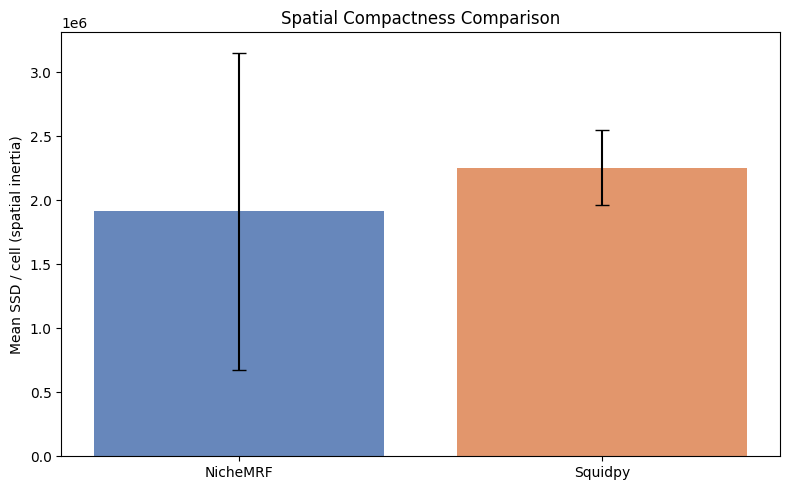

In [9]:
if ssd_data:
    # 4.1 Cross-method spatial SSD/cell comparison
    fig, ax = plt.subplots(figsize=(8, 5))

    methods = all_ssd['method'].unique()
    colors = {"NicheMRF": "#4C72B0", "Squidpy": "#DD8452"}

    means = all_ssd.groupby('method')['ssd_per_cell'].mean()
    stds = all_ssd.groupby('method')['ssd_per_cell'].std()

    x = np.arange(len(methods))
    ax.bar(x, [means[m] for m in methods], yerr=[stds[m] for m in methods],
           color=[colors.get(m, "gray") for m in methods], alpha=0.85, capsize=5)

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel("Mean SSD / cell (spatial inertia)")
    ax.set_title("Spatial Compactness Comparison")

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "cross_method_ssd_comparison.png"), dpi=150)
    plt.show()

## 5. Niche-Specific Details

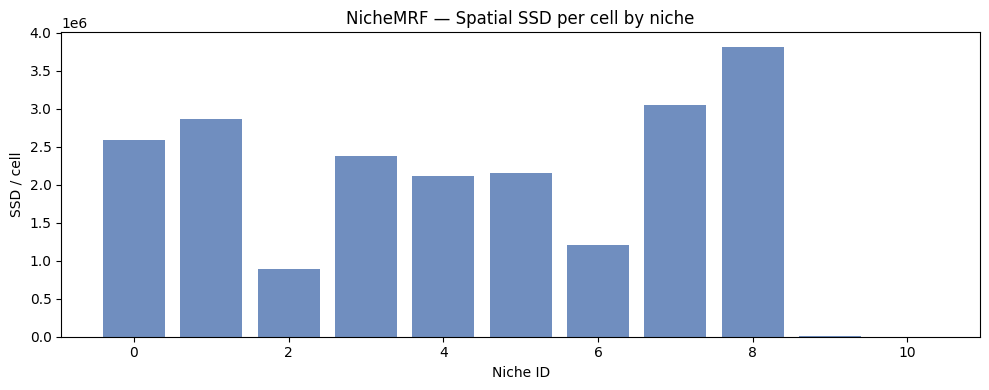

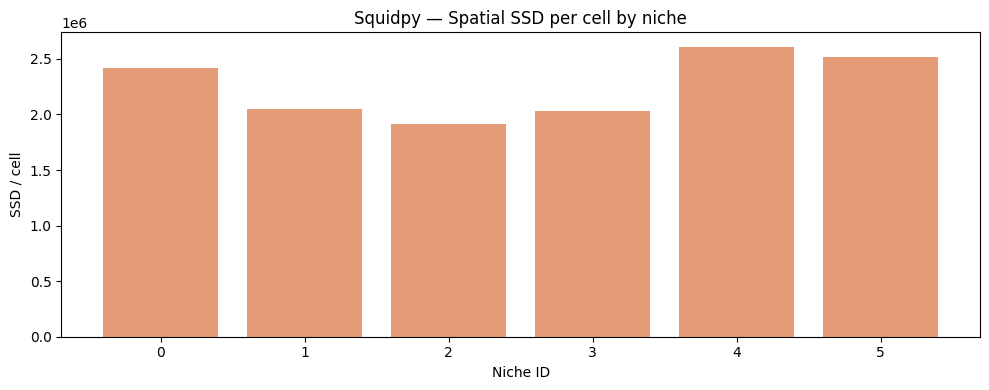

In [10]:
if ssd_data:
    for method in methods:
        df = all_ssd[all_ssd['method'] == method]
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(df['niche'], df['ssd_per_cell'], color=colors.get(method, "gray"), alpha=0.8)
        ax.set_title(f"{method} — Spatial SSD per cell by niche")
        ax.set_xlabel("Niche ID")
        ax.set_ylabel("SSD / cell")
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"{method.lower()}_cluster_ssd.png"), dpi=150)
        plt.show()

## 6. Export Results to Google Drive

In [11]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define destination folder
drive_dest = "/content/drive/MyDrive/CBMF4761/"
os.makedirs(drive_dest, exist_ok=True)

# Copy results directory contents to Drive
if os.path.exists(RESULTS_DIR):
    print(f"Copying results from {RESULTS_DIR} to {drive_dest}...")
    for item in os.listdir(RESULTS_DIR):
        s = os.path.join(RESULTS_DIR, item)
        d = os.path.join(drive_dest, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)
    print("Export complete.")
else:
    print("Error: Results directory not found.")

Mounted at /content/drive
Copying results from ../results to /content/drive/MyDrive/CBMF4761/...
Export complete.
